# **Imports**

In [1]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 5.4 MB/s 
     |████████████████████████████████| 9.5 MB 36.4 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-hi5_jpx3
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-hi5_jpx3
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997337 sha256=876dd293b7acf561bc57c1e78528d37b2ba05d2e0ad885da9a9b9ad805689415
  Stored in directory: /tmp/pip-ephem-wheel-cache-g3z0eqvf/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7c

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [3]:
!gdown --id 1OMG94NnRSXtjbm5eSLQ-n9WXL6rJxZ-N

Downloading...
From: https://drive.google.com/uc?id=1OMG94NnRSXtjbm5eSLQ-n9WXL6rJxZ-N
To: /content/TCS.NS.csv
100% 151k/151k [00:00<00:00, 67.8MB/s]


In [4]:
stock_name="TCS"

In [5]:
df_stock = pd.read_csv('TCS.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,1219.500000,1219.500000,1206.125000,1208.199951,712262.0,4,1,1,7791.299805,13.375000
2016-01-04,1205.074951,1207.000000,1183.025024,1184.800049,1870184.0,0,4,1,7784.649902,23.974976
2016-01-05,1192.500000,1193.300049,1170.500000,1174.474976,2678020.0,1,5,1,7741.000000,22.800049
2016-01-06,1175.099976,1193.074951,1175.099976,1190.800049,2653228.0,2,6,1,7568.299805,17.974976
2016-01-07,1185.000000,1191.449951,1180.000000,1185.625000,3199580.0,3,7,1,7601.350098,11.449951


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [6]:
df_stock['Close'].head()

Date
2016-01-01    1208.199951
2016-01-04    1184.800049
2016-01-05    1174.474976
2016-01-06    1190.800049
2016-01-07    1185.625000
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - TCS')

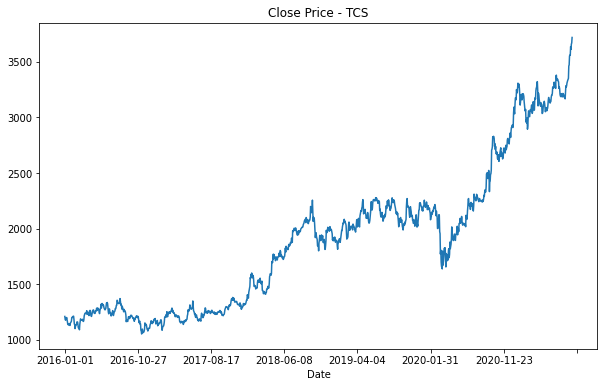

In [7]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

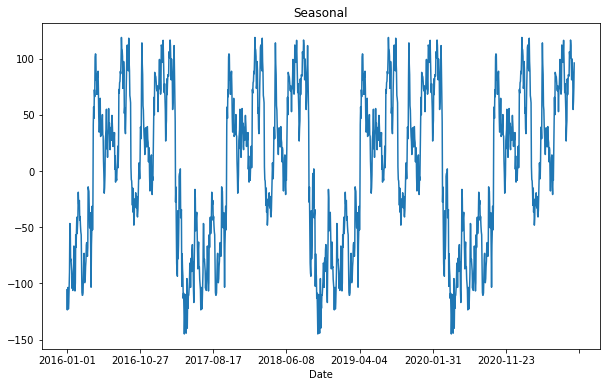

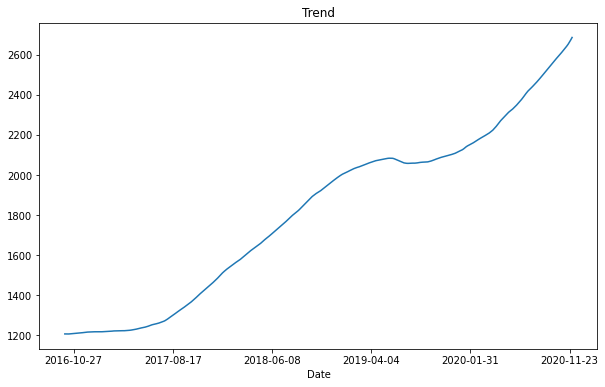

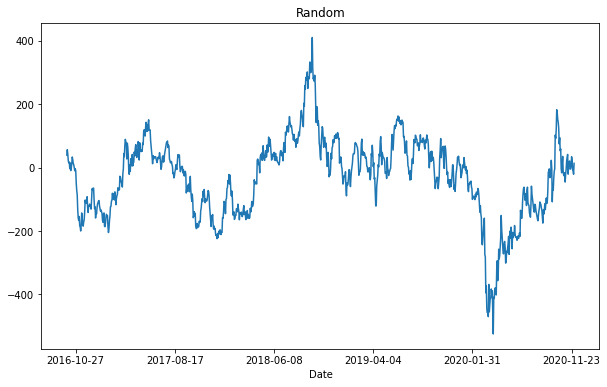

In [8]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [9]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.9932601319425032
4.388402066426483e-28
Test Statistic                -1.529517e+01
p-value                        4.388402e-28
#lags used                     4.000000e+00
number of observations used    1.382000e+03
critical value (1%)           -3.435091e+00
critical value (5%)           -2.863634e+00
critical value (10%)          -2.567885e+00
dtype: float64
Differencing Value :  2


##*ACF*

In [10]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.         -0.02618226 -0.03809466  0.00263798  0.02191219  0.0783723
 -0.02893968  0.02241397 -0.03495071 -0.01875504  0.02569078 -0.04858118
  0.02595114 -0.00748183  0.00186841  0.03535851 -0.0190179  -0.01337328
 -0.06409619 -0.01808562  0.05524923]


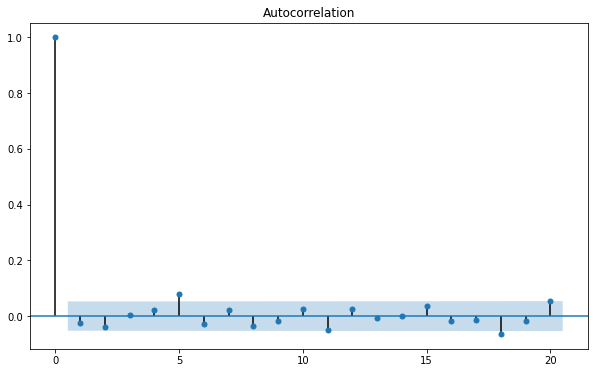

In [11]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [12]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.00000000e+00 -2.62011491e-02 -3.88628487e-02  5.88327726e-04
  2.06261811e-02  8.01486660e-02 -2.32077149e-02  2.72330113e-02
 -3.72254268e-02 -2.23821604e-02  1.67965800e-02 -4.66126421e-02
  2.31269624e-02 -2.38352552e-03  3.95122169e-03  3.54799512e-02
 -1.05191772e-02 -2.02065150e-02 -6.32337802e-02 -2.96028923e-02
  4.59642945e-02]


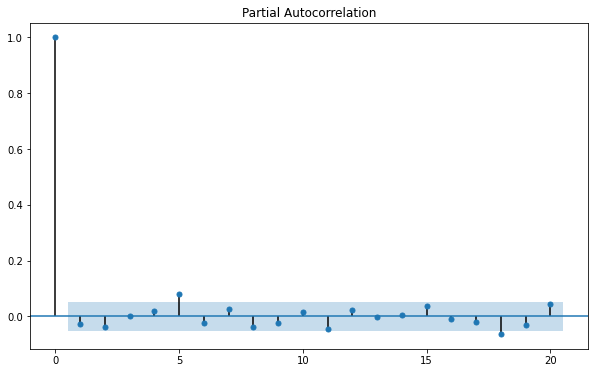

In [13]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [14]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [15]:
df_stock_train.tail()

Date
2021-07-26    3197.550049
2021-07-27    3182.949951
2021-07-28    3197.800049
2021-07-29    3195.800049
2021-07-30    3167.449951
Name: Close, dtype: float64

In [16]:
df_stock_test.head()

Date
2021-08-02    3219.399902
2021-08-03    3284.899902
2021-08-04    3273.949951
2021-08-05    3283.949951
2021-08-06    3309.800049
Name: Close, dtype: float64

##*Model Fitting*

In [17]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [18]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(0, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

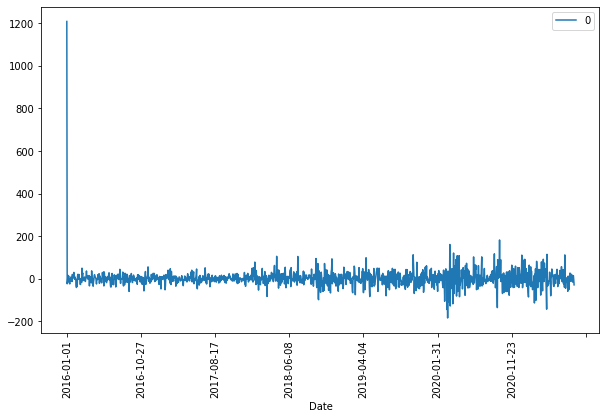

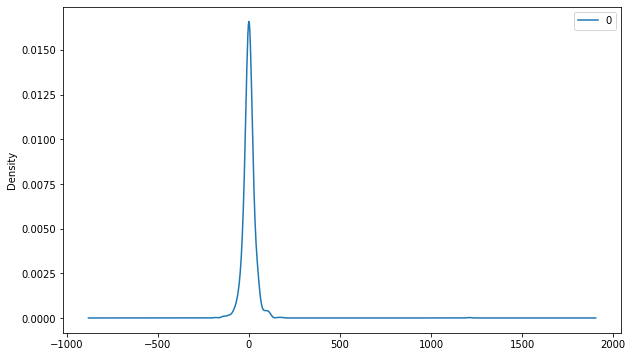

                 0
count  1369.000000
mean      2.313696
std      45.145576
min    -183.849976
25%     -13.200073
50%       0.900146
75%      15.949951
max    1208.199951


In [19]:
model = ARIMA(df_stock_train, order=(0,1,0))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [20]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 1.3049651124978185


([], <a list of 0 Text major ticklabel objects>)

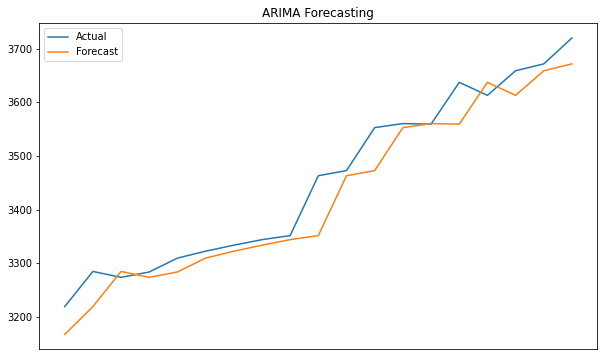

In [21]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [22]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [23]:
predictions

[3167.449951171875,
 3219.39990234375,
 3284.89990234375,
 3273.949951171875,
 3283.949951171875,
 3309.800048828125,
 3322.699951171875,
 3333.89990234375,
 3344.199951171875,
 3351.75,
 3463.39990234375,
 3472.949951171875,
 3553.050048828125,
 3560.550048828125]

#**MARS - Multivariate Adaptive Regression Splines**

In [24]:
from pyearth import Earth

In [25]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [26]:
df_stock_mars_train.shape

(1369, 5)

In [27]:
df_stock_mars_test.shape

(19, 5)

In [28]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,1219.500000,1219.500000,1206.125000,1208.199951,712262.0
2016-01-04,1205.074951,1207.000000,1183.025024,1184.800049,1870184.0
2016-01-05,1192.500000,1193.300049,1170.500000,1174.474976,2678020.0
2016-01-06,1175.099976,1193.074951,1175.099976,1190.800049,2653228.0
2016-01-07,1185.000000,1191.449951,1180.000000,1185.625000,3199580.0


In [29]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,3180.000000,3224.899902,3167.000000,3219.399902,2608669.0
2021-08-03,3229.000000,3290.000000,3218.949951,3284.899902,3804735.0
2021-08-04,3300.000000,3305.199951,3261.199951,3273.949951,2929598.0
2021-08-05,3275.000000,3315.000000,3262.500000,3283.949951,2534521.0
2021-08-06,3272.550049,3324.000000,3265.000000,3309.800049,2292362.0
2021-08-09,3323.899902,3337.000000,3310.000000,3322.699951,1510489.0
2021-08-10,3315.600098,3349.899902,3315.600098,3333.899902,2040777.0
2021-08-11,3350.000000,3360.000000,3327.100098,3344.199951,1929707.0
2021-08-12,3326.000000,3368.000000,3326.000000,3351.750000,1310205.0


In [30]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [31]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [32]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 19.62
RMSE/Mean 0.6


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

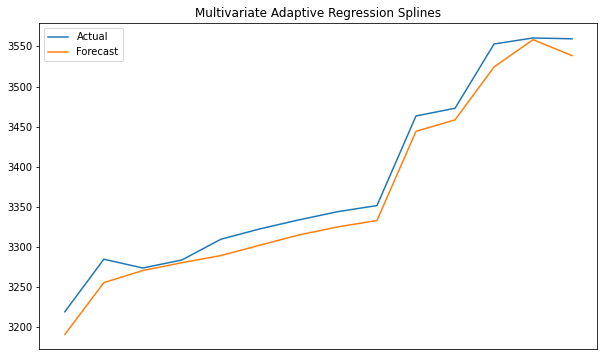

In [33]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [34]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [35]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [36]:
df_stock_var_train.shape

(1369, 4)

In [37]:
df_stock_var_test.shape

(14, 4)

In [38]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [39]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

##*Granger Causality Test*

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0000,0.0000,0.0,0.0
High_y,0.0000,1.0000,0.0,0.0
Low_y,0.0000,0.0000,1.0,0.0
Close_y,0.0015,0.0498,0.0,1.0


##*Cointegration Test*

In [41]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  476.01    > 40.1749   =>   True
High   ::  260.6     > 24.2761   =>   True
Low    ::  69.58     > 12.3212   =>   True
Close  ::  5.04      > 4.1296    =>   True


##*ADF Test*

In [42]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [43]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 0.1847
 No. Lags Chosen       = 2
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9714. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 0.0918
 No. Lags Chosen       = 9
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9655. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root.

##*ADF Test on first order differencing*

In [44]:
df_differenced = df_stock_var_train.diff().dropna()

In [45]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -27.7122
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -12.7594
 No. Lags Chosen       = 8
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05

##*Selecting the number of lags*

In [46]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,24.74,24.75,5.527e+10,24.74
1,23.11,23.18,1.083e+10,23.13
2,22.66,22.80,6.952e+09,22.71
3,22.47,22.67,5.711e+09,22.54
4,22.34,22.60,5.046e+09,22.44
5,22.21,22.53*,4.412e+09,22.33
6,22.18,22.56,4.282e+09,22.32
7,22.13,22.58,4.086e+09,22.30
8,22.12,22.63,4.034e+09,22.31
9,22.08,22.65,3.892e+09,22.30*


##*Fitting the model*

In [47]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     12:35:18
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    23.2589
Nobs:                     1348.00    HQIC:                   22.4762
Log likelihood:          -22160.0    FPE:                3.61420e+09
AIC:                      22.0076    Det(Omega_mle):     2.86182e+09
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.264493         0.408765            0.647           0.518
L1.Open          -0.924925         0.038050          -24.308           0.000
L1.High           0.037378         0.038607            0.968           0.333


##*Durbin Watson Test*

In [48]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 1.99
High : 2.0
Low : 2.0
Close : 2.0


##*Getting the Forecast*

In [49]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

20


array([[-27.        , -22.30004883, -37.15014648, -16.05004883],
       [ 11.        ,  34.30004883,   6.80004883,  -4.44995117],
       [-29.        , -46.        , -45.89990234, -58.69995117],
       [-38.        , -45.30004883, -14.5       ,  12.64990234],
       [ 23.        ,  15.30004883,  -9.70019531, -16.44995117],
       [-48.        , -16.        , -30.89990234, -50.35009766],
       [-15.        , -46.        , -12.64990234, -15.04980469],
       [-21.        , -22.        , -13.35009766,  -5.55004883],
       [-27.        ,   8.        ,  10.        ,  27.        ],
       [ 40.60009766,   9.85009766,   9.        , -11.60009766],
       [-14.60009766, -12.        ,  -2.        ,  -8.14990234],
       [-33.        , -20.05004883, -16.        , -10.19995117],
       [  4.60009766,  15.19995117, -19.85009766,  21.19995117],
       [  5.39990234,   9.94995117,  33.85009766,  10.55004883],
       [ 40.        ,  16.60009766,  16.64990234,  -3.5       ],
       [-30.        , -17

In [50]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,-48.799765,-32.043941,-26.288911,-2.045538
2021-08-03,5.467847,13.496021,14.646553,12.153451
2021-08-04,13.377562,11.788470,14.698031,19.424172
2021-08-05,-1.672297,-3.727615,3.785055,-8.644854
2021-08-06,13.391861,11.776055,9.290798,11.046862
2021-08-09,12.967825,13.909510,10.877767,18.514861
2021-08-10,10.374182,0.695421,10.717286,1.877599
2021-08-11,6.642713,11.088415,6.073353,8.846882
2021-08-12,-4.737881,-1.596261,0.215585,-6.159559


##*Inverting forecast back to original scale*

In [51]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [52]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,3170.200235,3191.456059,3136.061187,3165.404413
2021-08-03,3175.668082,3204.952080,3150.707740,3177.557864
2021-08-04,3189.045644,3216.740550,3165.405771,3196.982036
2021-08-05,3187.373347,3213.012936,3169.190826,3188.337182
2021-08-06,3200.765208,3224.788991,3178.481624,3199.384044
2021-08-09,3213.733032,3238.698501,3189.359391,3217.898905
2021-08-10,3224.107214,3239.393922,3200.076677,3219.776504
2021-08-11,3230.749927,3250.482337,3206.150031,3228.623386
2021-08-12,3226.012047,3248.886076,3206.365616,3222.463827


##*Plotting Forecast vs Actual*

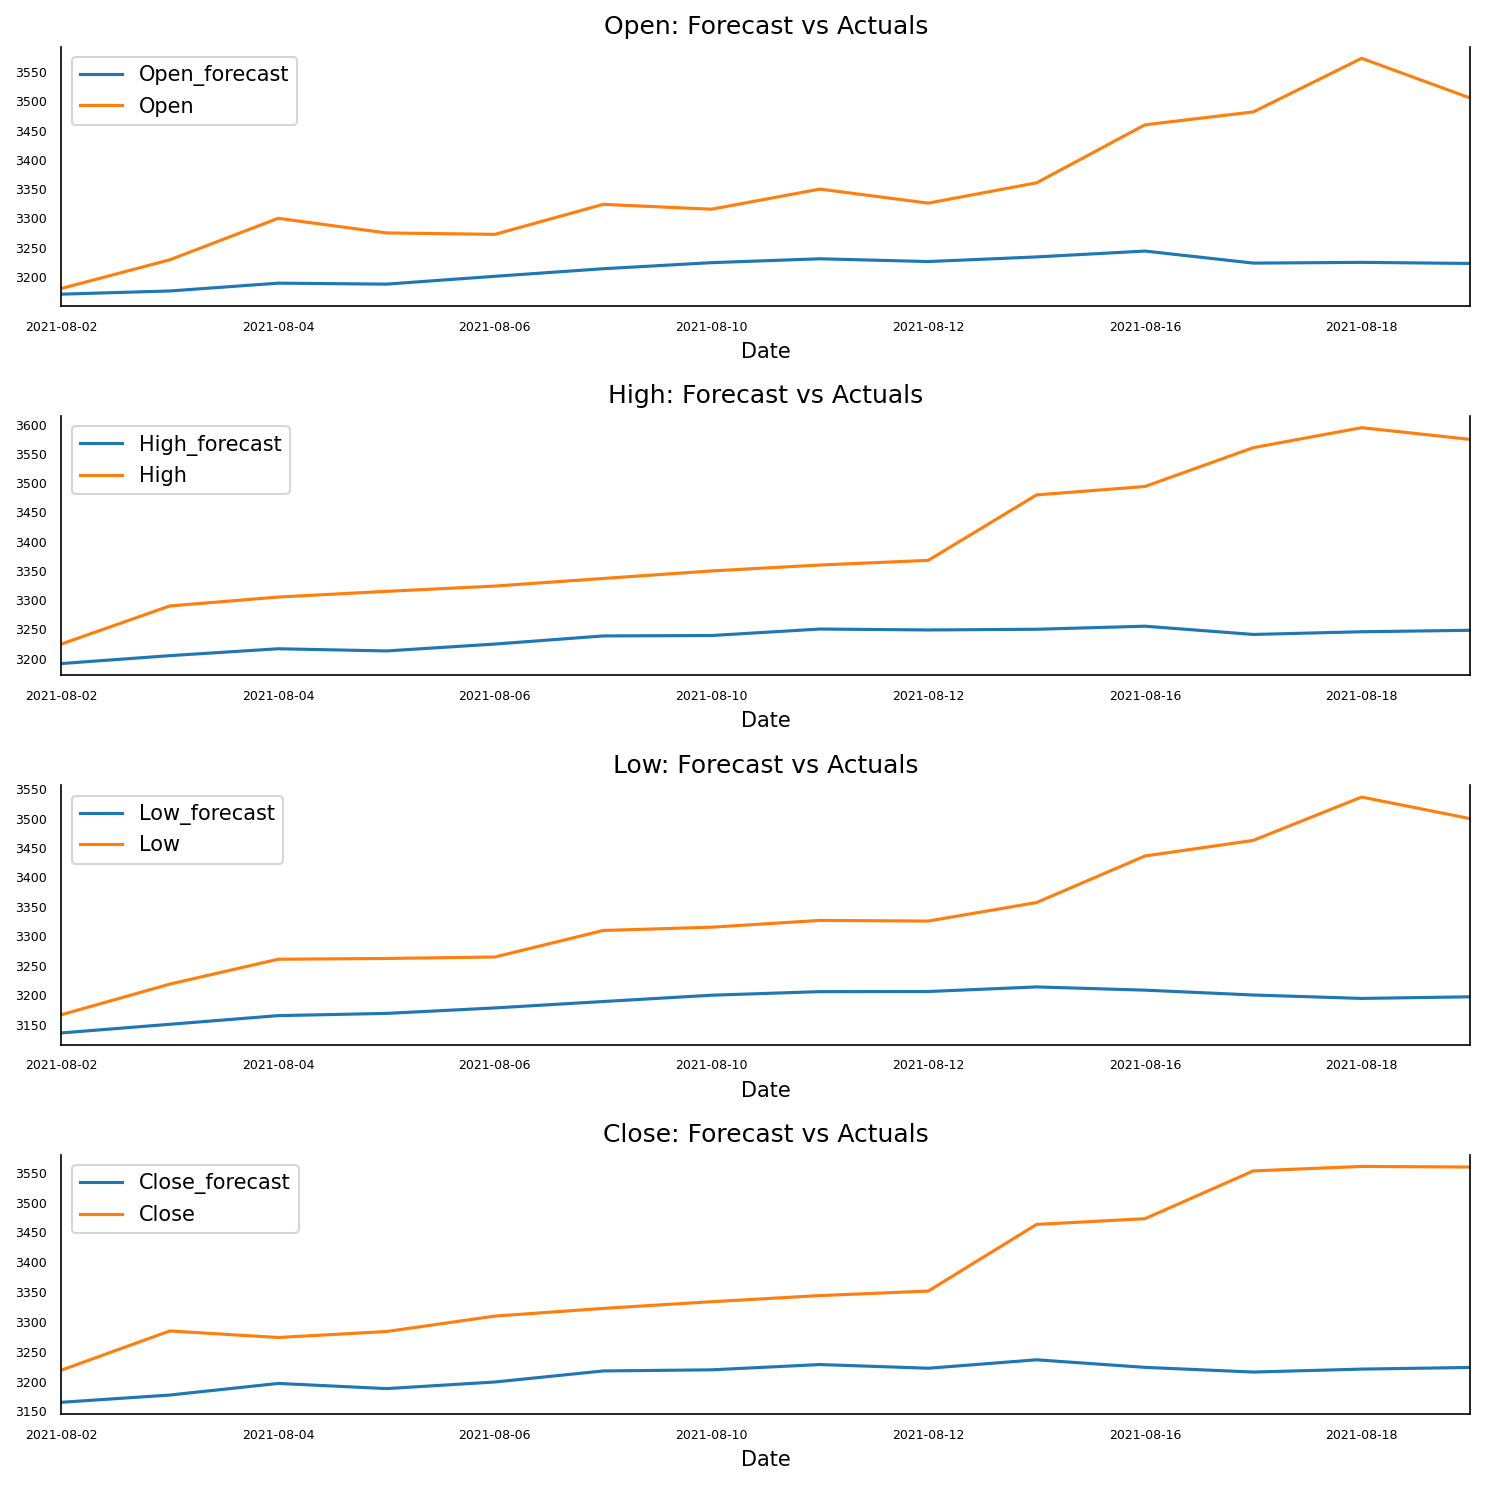

In [53]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [54]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  170.0187
rmse_mean :  5.0693

Forecast Accuracy of High
rmse :  193.6869
rmse_mean :  5.6992

Forecast Accuracy of Low
rmse :  176.825
rmse_mean :  5.2956

Forecast Accuracy of Close
rmse :  198.3529
rmse_mean :  5.8667


#**Linear Regression**

In [55]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [58]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.069030,0.064173,0.077526,1208.199951,0.007109,4,1,1,0.091661,0.023632
2016-01-04,0.062847,0.058807,0.067587,1184.800049,0.020270,0,4,1,0.090919,0.058064
2016-01-05,0.057457,0.052926,0.062197,1174.474976,0.029452,1,5,1,0.086044,0.054247
2016-01-06,0.049999,0.052830,0.064177,1190.800049,0.029170,2,6,1,0.066755,0.038574
2016-01-07,0.054242,0.052132,0.066285,1185.625000,0.035380,3,7,1,0.070447,0.017379


In [59]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.909346,0.924989,0.921258,3219.399902,0.028664,0,2,8,1.023069,0.168264
2021-08-03,0.930349,0.952933,0.943611,3284.899902,0.042258,1,3,8,1.037370,0.210980
2021-08-04,0.960781,0.959457,0.961791,3273.949951,0.032311,2,4,8,1.041369,0.123112
2021-08-05,0.950065,0.963664,0.962350,3283.949951,0.027821,3,5,8,1.035070,0.150723
2021-08-06,0.949015,0.967527,0.963426,3309.800049,0.025069,4,6,8,1.037309,0.171837


##*Checking for multicollinearity*

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [61]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [62]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [63]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [64]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [65]:
print(model.summary2())

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.880     
Dependent Variable: Close            AIC:                18637.6723
Date:               2021-09-15 12:35 BIC:                18689.8907
No. Observations:   1369             Log-Likelihood:     -9308.8   
Df Model:           9                F-statistic:        1116.     
Df Residuals:       1359             Prob (F-statistic): 0.00      
R-squared:          0.881            Scale:              47521.    
-------------------------------------------------------------------
                Coef.   Std.Err.    t    P>|t|    [0.025    0.975] 
-------------------------------------------------------------------
NIFTY50       2357.7035  27.9497 84.3552 0.0000 2302.8742 2412.5327
Range         1447.5250  74.7699 19.3597 0.0000 1300.8480 1594.2020
Day of Week_0  692.7610  18.3164 37.8220 0.0000  656.8296  728.6924
Day of Week_1  708.2396  18.0151 39.3136 0.0000  672.8992  743.580

In [66]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


NIFTY50
Range
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Month_5
Month_6
Month_8


In [67]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
4.19260584802029
